# 03.1 — 공정 평가 (per-split ensemble refit, 논문 프로토콜)

**기존 nb 03 과의 차이**:
- 각 split 에서 **X_tr 만으로** K-member ensemble fit (X_te 안 봄 → data leakage 없음)
- VP-SGLD synthetic 도 **split 마다 새로** 생성 (split-dependent)
- `N_SYN_PER_CLASS = 250` (논문 기준, real:syn ≈ 1:5)

**프로토콜**: TabEBM 논문 `run_experiment.py` 와 동일.

**시간 예상**: ProcessPool 4 GPU 기준 ~20 분.

## 0. Setup

In [11]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys, json, time, datetime as _dt, shutil
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as _mp
try: _mp.set_start_method('spawn', force=True)
except RuntimeError: pass

os.chdir('/home/work/JooKyung/TabEBM')
sys.path.insert(0, 'experiments'); sys.path.insert(0, 'src')

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

pd.set_option('display.width', 220); pd.set_option('display.precision', 3)
print('ready')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ready


## 1. 사용 가능한 ENSEMBLE 목록

In [12]:
for p in sorted(Path('experiments/ebms').iterdir()):
    if p.is_dir() and p.name.endswith('_EBM'):
        print(f'  {p.name}')


  20260415_184742_CornerNoise-Distance-NumFakeCorners_EBM
  20260415_190012_CornerNoise-Distance-NumFakeCorners_EBM
  20260415_200422_Distance_EBM
  20260415_203146_Subsample_EBM
  20260415_204431_Subsample_EBM
  20260415_205240_Subsample-Distance_EBM
  20260415_205627_Subsample-Distance_EBM
  20260415_210238_Subsample-Distance_EBM
  20260415_210323_Distance_EBM
  20260415_210358_Distance_EBM
  20260415_210502_Distance_EBM
  20260415_211901_Distance_EBM
  20260415_213635_Subsample-Distance_EBM
  20260415_214026_Distance_EBM
  20260417_201751_Distance_EBM


## 2. ENSEMBLE 선택

In [13]:
ENSEMBLE_ROOT = Path('experiments/ebms/20260415_214026_Distance_EBM')  # ← 변경
assert (ENSEMBLE_ROOT / 'c0').exists()
print(f'ENSEMBLE_ROOT = {ENSEMBLE_ROOT}')


ENSEMBLE_ROOT = experiments/ebms/20260415_214026_Distance_EBM


## 3. 선택한 ENSEMBLE 의 원본 학습 설정 확인

이 ensemble 이 원래 어떤 설정으로 fit 됐는지 자동 감지.
아래 § 6 에서 per-split refit 용 설정을 선택할 때 참고.

In [14]:
# --- 앙상블 학습 설정 자동 감지 ---
_meta_path = ENSEMBLE_ROOT / 'meta.json'
_ens_meta = json.loads(_meta_path.read_text()) if _meta_path.exists() else {}
_member0_path = ENSEMBLE_ROOT / 'c0' / 'ebm_0' / 'config.json'
_member0_cfg = json.loads(_member0_path.read_text()) if _member0_path.exists() else {}

_methods_detected = _ens_meta.get('methods', _ens_meta.get('methods_list', []))
_K_detected = _ens_meta.get('n_ebms', '?')
_corner_seed = _member0_cfg.get('corner_seed')
_member_seed = _member0_cfg.get('seed')
# corner_seed 없으면 (구 ensemble) → seed+k 로 corner 뽑았으므로 shared=False 추정
_shared_detected = not (_corner_seed == _member_seed) if _corner_seed is not None else False  # 구 ensemble: per-member corner (shared=False)
_sub_ratio = _member0_cfg.get('method_subsample', {}).get('ratio', '-')
_alphas = []
for k in range(int(_K_detected) if str(_K_detected).isdigit() else 0):
    _p = ENSEMBLE_ROOT / 'c0' / f'ebm_{k}' / 'config.json'
    if _p.exists():
        _a = json.loads(_p.read_text()).get('method_distance', {}).get('neg_distance')
        if _a is not None: _alphas.append(_a)

print(f'=== 이 ensemble 의 원본 학습 설정 (자동 감지) ===')
print(f'  methods:        {_methods_detected}')
print(f'  K:              {_K_detected}')
_cs_note = '' if _corner_seed is not None else '  (corner_seed 없는 구 ensemble → per-member 추정)'
print(f'  shared_corners: {_shared_detected}{_cs_note}')
print(f'  subsample:      ratio={_sub_ratio}')
if _alphas:
    print(f'  distance:       α={min(_alphas):.2f}..{max(_alphas):.2f}')
print(f'\n→ § 6 에서 per-split refit 설정을 이 값 기준으로 선택하거나 다르게 override.')


=== 이 ensemble 의 원본 학습 설정 (자동 감지) ===
  methods:        ['Distance']
  K:              10
  shared_corners: False  (corner_seed 없는 구 ensemble → per-member 추정)
  subsample:      ratio=-
  distance:       α=2.00..2.00

→ § 6 에서 per-split refit 설정을 이 값 기준으로 선택하거나 다르게 override.


## 4. 사용 가능한 SESSION 목록

In [15]:
sessions_root = ENSEMBLE_ROOT / 'comparisons' / 'sessions'
if sessions_root.exists():
    for s in sorted(sessions_root.iterdir()):
        if s.is_dir():
            n = sum(1 for p in (s/'sweeps').iterdir() if p.is_dir()) if (s/'sweeps').exists() else 0
            print(f'  {s.name:<55}  ({n} folders)')
else:
    print('  (no sessions — nb 02.2 먼저 실행)')


  20260416_191851_all_axes_baseline                        (29 folders)
  20260416_212804_smoke_test                               (3 folders)
  20260416_213022_user_test_4tasks                         (2 folders)
  20260416_213939_all_axes_baseline                        (29 folders)
  20260417_160451_all_axes_baseline                        (19 folders)
  20260417_165505_all_axes_baseline                        (21 folders)
  20260417_180630_all_axes_baseline                        (21 folders)
  20260417_182036_all_axes_baseline                        (21 folders)


## 5. SESSION 선택

In [16]:
SESSION_DIR = sessions_root / '20260417_182036_all_axes_baseline'  # ← 변경
SWEEPS_DIR = SESSION_DIR / 'sweeps'
assert SWEEPS_DIR.exists(), f'not found: {SWEEPS_DIR}'
print(f'SESSION_DIR = {SESSION_DIR}')


SESSION_DIR = experiments/ebms/20260415_214026_Distance_EBM/comparisons/sessions/20260417_182036_all_axes_baseline


## 6. 선택한 session 의 config (folder) 목록

In [17]:
all_folders = sorted(p.name for p in SWEEPS_DIR.iterdir()
                      if p.is_dir() and (p / 'run_config.json').exists())
for i, f in enumerate(all_folders):
    cfg = json.loads((SWEEPS_DIR / f / 'run_config.json').read_text())['cfg']
    print(f'  [{i:>2d}] {f:<30}  '
           f'β={cfg["beta"]:<8g} η={cfg["eta"]:<6g} τ={cfg["tau"]:<5g} '
           f'σ={cfg["sigma_start"]:<5g} T={cfg["n_steps"]:<4d} '
           f'ig_var={cfg.get("ignore_variance", False)}')


  [ 0] baseline                        β=1e+06    η=0.05   τ=1     σ=0.1   T=50   ig_var=False
  [ 1] beta__10000000                  β=1e+07    η=0.05   τ=1     σ=0.1   T=50   ig_var=False
  [ 2] beta__100000000                 β=1e+08    η=0.05   τ=1     σ=0.1   T=50   ig_var=False
  [ 3] beta__1000000000                β=1e+09    η=0.05   τ=1     σ=0.1   T=50   ig_var=False
  [ 4] beta__10000000000               β=1e+10    η=0.05   τ=1     σ=0.1   T=50   ig_var=False
  [ 5] beta__100000000000              β=1e+11    η=0.05   τ=1     σ=0.1   T=50   ig_var=False
  [ 6] eta__0.01                       β=1e+06    η=0.01   τ=1     σ=0.1   T=50   ig_var=False
  [ 7] eta__0.1                        β=1e+06    η=0.1    τ=1     σ=0.1   T=50   ig_var=False
  [ 8] eta__0.2                        β=1e+06    η=0.2    τ=1     σ=0.1   T=50   ig_var=False
  [ 9] eta__1.0                        β=1e+06    η=1      τ=1     σ=0.1   T=50   ig_var=False
  [10] ignore_variance__False          β=1e+06    

## 7. 평가할 config 선택 + ensemble 설정

선택한 folder 에서 config 자동 추출. 추가로 평가 파라미터 조정.

In [18]:
# --- 평가할 folder 선택 (None = 전부) ---
SELECTED_FOLDERS = ['baseline', 'beta__10000000', 'beta__100000000', 'beta__1000000000', 'beta__10000000000', 'beta__100000000000']   # ← 원하는 것만
# SELECTED_FOLDERS = None   # ← 전부

if SELECTED_FOLDERS is None:
    SELECTED_FOLDERS = all_folders
missing = [f for f in SELECTED_FOLDERS if f not in all_folders]
assert not missing, f'없는 folder: {missing}'

# sweep folder 에서 VP config dict 추출
VP_CONFIGS = []
for fn in SELECTED_FOLDERS:
    rc = json.loads((SWEEPS_DIR / fn / 'run_config.json').read_text())
    cfg = rc['cfg']
    VP_CONFIGS.append(dict(
        name=f'vp_{fn}',
        beta=cfg['beta'], eta=cfg['eta'], tau=cfg['tau'],
        sigma_start=cfg['sigma_start'], n_steps=cfg['n_steps'],
        auto_beta=cfg['auto_beta'],
        ignore_variance=cfg.get('ignore_variance', False),
    ))

# === ensemble fit 설정 (per-split) — 반드시 선택해야 실행됨 ==================
# 아래 3 가지 preset 중 하나를 주석 해제하거나, 직접 편집.
# 전부 주석이면 assert 로 멈춤.
#
# --- Preset A: corner diversity 만 (가장 심플, 논문 비교용) ---
# 위 § 2.5 에서 감지된 원본 설정과 다를 수 있음 — per-split refit 에 쓸 설정.
ENSEMBLE_METHODS = ['Distance']
ENSEMBLE_METHOD_PARAMS = {'Distance':{'mode': 'fixed', 'value': 2.0}}
SHARED_CORNERS = False              # 멤버마다 다른 corner vertex → 자연 diversity
K = 10

# --- Preset B: Subsample 만 (25% subset diversity) ---
# ENSEMBLE_METHODS = ['Subsample']
# ENSEMBLE_METHOD_PARAMS = {'Subsample': {'ratio': 0.25}}
# SHARED_CORNERS = True
# K = 10

# --- Preset C: Subsample + Distance sweep (최대 diversity) ---
# ENSEMBLE_METHODS = ['Subsample', 'Distance']
# ENSEMBLE_METHOD_PARAMS = {'Subsample': {'ratio': 0.25},
#                            'Distance': {'mode': 'sweep', 'dist_range': [1.0, 10.0]}}
# SHARED_CORNERS = True
# K = 10

# --- Preset D: 직접 설정 ---
# ENSEMBLE_METHODS = [...]
# ENSEMBLE_METHOD_PARAMS = {...}
# SHARED_CORNERS = True / False
# K = ...

# --- Preset E: § 2.5 에서 감지된 원본 설정 그대로 (ensemble 과 동일 재현) ---
# ENSEMBLE_METHODS = _methods_detected
# ENSEMBLE_METHOD_PARAMS = {}       # 원본 params 는 config.json 에서 자동 적용됨
# SHARED_CORNERS = _shared_detected if isinstance(_shared_detected, bool) else True
# K = int(_K_detected) if str(_K_detected).isdigit() else 10
# ==========================================================================

# 설정 검증
assert 'K' in dir() and 'SHARED_CORNERS' in dir(), \
    '앙상블 설정 안 됨 — 위 Preset A/B/C/D 중 하나를 주석 해제하세요'
assert isinstance(K, int) and K >= 2, f'K={K} 는 2 이상이어야'

_ens_tag = f'methods={ENSEMBLE_METHODS}, shared_corners={SHARED_CORNERS}, K={K}'
print(f'Ensemble 설정: {_ens_tag}')

# --- 평가 설정 (논문 기준) ---
CLASSIFIERS     = ['knn', 'lr', 'rf', 'xgboost', 'mlp']
SEED            = 42
N_SPLITS        = 10
N_SYN_PER_CLASS = 250    # 논문 기준 (n_syn=500 / 2 classes, ratio ~1:5)
GPUS            = [0, 1, 2, 3]

# --- 출력 ---
import datetime as _dt
ts = _dt.datetime.now().strftime('%Y%m%d_%H%M%S')
OUT_DIR = ENSEMBLE_ROOT / 'fair_eval' / ts
OUT_DIR.mkdir(parents=True, exist_ok=True)

def make_clf(name, seed=0):
    if name == 'knn':     return KNeighborsClassifier(n_jobs=-1)
    if name == 'lr':      return LogisticRegression(max_iter=1000, n_jobs=-1, random_state=seed)
    if name == 'rf':      return RandomForestClassifier(n_jobs=-1, random_state=seed)
    if name == 'xgboost': return xgb.XGBClassifier(n_jobs=-1, eval_metric='logloss', use_label_encoder=False, random_state=seed)
    if name == 'mlp':     return MLPClassifier(max_iter=300, random_state=seed)
    raise ValueError(name)

(OUT_DIR / 'eval_config.json').write_text(json.dumps({
    'ENSEMBLE_ROOT': str(ENSEMBLE_ROOT),
    'SESSION_DIR': str(SESSION_DIR),
    'SELECTED_FOLDERS': SELECTED_FOLDERS,
    'VP_CONFIGS': VP_CONFIGS,
    'ENSEMBLE_METHODS': ENSEMBLE_METHODS,
    'ENSEMBLE_METHOD_PARAMS': ENSEMBLE_METHOD_PARAMS,
    'SHARED_CORNERS': SHARED_CORNERS, 'K': K,
    'CLASSIFIERS': CLASSIFIERS, 'SEED': SEED,
    'N_SPLITS': N_SPLITS, 'N_SYN_PER_CLASS': N_SYN_PER_CLASS,
}, indent=2, default=str))

print(f'선택: {len(VP_CONFIGS)} VP configs:')
for c in VP_CONFIGS:
    print(f'  {c["name"]:<30} β={c["beta"]:<8g} η={c["eta"]:<6g} '
           f'τ={c["tau"]:<5g} ig_var={c["ignore_variance"]}')
print(f'\nN_SYN_PER_CLASS: {N_SYN_PER_CLASS}')
print(f'OUT_DIR: {OUT_DIR}')


Ensemble 설정: methods=['Distance'], shared_corners=False, K=10
선택: 6 VP configs:
  vp_baseline                    β=1e+06    η=0.05   τ=1     ig_var=False
  vp_beta__10000000              β=1e+07    η=0.05   τ=1     ig_var=False
  vp_beta__100000000             β=1e+08    η=0.05   τ=1     ig_var=False
  vp_beta__1000000000            β=1e+09    η=0.05   τ=1     ig_var=False
  vp_beta__10000000000           β=1e+10    η=0.05   τ=1     ig_var=False
  vp_beta__100000000000          β=1e+11    η=0.05   τ=1     ig_var=False

N_SYN_PER_CLASS: 250
OUT_DIR: experiments/ebms/20260415_214026_Distance_EBM/fair_eval/20260417_205640


## 8. 데이터 + split

In [19]:
data = np.load(ENSEMBLE_ROOT / 'c0' / 'class_data.npz')
X_all = data['X_all']; y_all = data['y_all']
CLASSES = sorted(np.unique(y_all).tolist())
print(f'X_all {X_all.shape}, classes {CLASSES}, bincount {np.bincount(y_all).tolist()}')

n_test = min(len(X_all) // 2, 500)
splits = [next(StratifiedShuffleSplit(n_splits=1, test_size=n_test, random_state=SEED+i).split(X_all, y_all))
          for i in range(N_SPLITS)]
print(f'{N_SPLITS} splits, test size = {n_test}')
print(f'train size per split: ~{len(splits[0][0])}')

X_all (100, 9), classes [0, 1], bincount [53, 47]
10 splits, test size = 50
train size per split: ~50


## 9. Per-split 평가 루프

각 split 마다:
1. X_tr 만으로 K-member **ensemble fit** (X_te 안 봄)
2. 해당 ensemble 로 각 VP config 의 **VP-SGLD synthetic** 생성
3. X_tr 만으로 **TabEBM single synthetic** 생성
4. **5 classifier × (baseline + single + N VP configs)** balanced accuracy 측정

In [20]:
from fair_eval_worker import fit_one_split_ensemble, run_one_sgld_task
from concurrent.futures import ProcessPoolExecutor, as_completed

VP_NAMES = [c['name'] for c in VP_CONFIGS]
SETTINGS = ['baseline', 'tabebm_single'] + VP_NAMES

split_ens_dir = OUT_DIR / 'per_split_ensembles'
split_ens_dir.mkdir(exist_ok=True)

N_GPU = len(GPUS)
PROCS_PER_GPU = 5

def _fmt(s):
    s = int(s); m, s = divmod(s, 60)
    return f'{m:d}m{s:02d}s' if m else f'{s:d}s'

# ============================================================
# Phase 1: ensemble fit — 10 splits (빠름, ~3s each)
# ============================================================
print('═══ Phase 1: per-split ensemble fit ═══', flush=True)
t1 = time.time()
ens_tasks = []
for split_i, (tr, te) in enumerate(splits):
    ens_tasks.append((
        split_i, tr, X_all, y_all, CLASSES,
        ENSEMBLE_METHODS, ENSEMBLE_METHOD_PARAMS,
        SHARED_CORNERS, K, SEED, str(split_ens_dir),
    ))

with ProcessPoolExecutor(max_workers=min(N_SPLITS, N_GPU * PROCS_PER_GPU)) as ex:
    futs = {ex.submit(fit_one_split_ensemble, t): t[0] for t in ens_tasks}
    for f in as_completed(futs):
        r = f.result()
        tag = '(cached)' if r.get('cached') else f'{r["dt"]:.1f}s'
        print(f'  split {r["split_i"]:>2d}  {tag}', flush=True)
print(f'  Phase 1 done — {time.time()-t1:.1f}s\n', flush=True)

# ============================================================
# Phase 2: SGLD tasks — flattened across splits/configs/classes
# ============================================================
print('═══ Phase 2: SGLD sampling (flattened) ═══', flush=True)
t2 = time.time()

sgld_tasks = []
task_id = 0
for split_i, (tr, te) in enumerate(splits):
    for ci, cfg in enumerate(VP_CONFIGS):
        for c in CLASSES:
            gpu = GPUS[task_id % N_GPU]
            sgld_tasks.append((
                'vp', split_i, c, {**cfg, '_ci': ci},
                tr, X_all, y_all,
                N_SYN_PER_CLASS, SEED, gpu, str(split_ens_dir),
            ))
            task_id += 1
    for c in CLASSES:
        gpu = GPUS[task_id % N_GPU]
        sgld_tasks.append((
            'single', split_i, c, SEED,
            tr, X_all, y_all,
            N_SYN_PER_CLASS, SEED, gpu, str(split_ens_dir),
        ))
        task_id += 1

n_total = len(sgld_tasks)
print(f'  {n_total} tasks  ({N_SPLITS} splits × '
      f'({len(VP_CONFIGS)} VP × {len(CLASSES)} cls + {len(CLASSES)} single))')
print(f'  {N_GPU} GPUs × {PROCS_PER_GPU} = {N_GPU*PROCS_PER_GPU} workers\n', flush=True)

# samples_bank[(split_i, cfg_name, class_c)] = np.ndarray
samples_bank = {}
done_count = 0

with ProcessPoolExecutor(max_workers=N_GPU * PROCS_PER_GPU) as ex:
    futs = {ex.submit(run_one_sgld_task, t): t for t in sgld_tasks}
    for f in as_completed(futs):
        r = f.result()
        key = (r['split_i'], r['cfg_name'], r['class_c'])
        samples_bank[key] = r['samples']
        done_count += 1
        if done_count % 10 == 0 or done_count == n_total:
            elapsed = time.time() - t2
            eta = elapsed / done_count * (n_total - done_count)
            print(f'  [{done_count:>3d}/{n_total}]  '
                  f'elapsed {_fmt(elapsed)}  ETA {_fmt(eta)}', flush=True)

print(f'  Phase 2 done — {_fmt(time.time()-t2)}\n', flush=True)

# ============================================================
# Phase 3: classifier eval (CPU)
# ============================================================
print('═══ Phase 3: classifier evaluation ═══', flush=True)
t3 = time.time()
all_rows = []

for split_i, (tr, te) in enumerate(splits):
    X_tr, y_tr = X_all[tr], y_all[tr]
    X_te, y_te = X_all[te], y_all[te]

    # baseline: train on real only
    base_scores = {}
    for clf_name in CLASSIFIERS:
        clf = make_clf(clf_name, seed=SEED + split_i)
        clf.fit(X_tr, y_tr)
        base_scores[clf_name] = balanced_accuracy_score(y_te, clf.predict(X_te)) * 100

    # augmented settings
    aug_settings = {}
    # tabebm_single
    single_samples = {}
    for c in CLASSES:
        single_samples[c] = samples_bank[(split_i, 'tabebm_single', c)]
    X_single = np.vstack([X_tr] + [single_samples[c] for c in CLASSES])
    y_single = np.concatenate([y_tr] + [np.full(len(single_samples[c]), c) for c in CLASSES])
    aug_settings['tabebm_single'] = (X_single, y_single)

    # VP configs
    for cfg in VP_CONFIGS:
        vp_samples = {}
        for c in CLASSES:
            vp_samples[c] = samples_bank[(split_i, cfg['name'], c)]
        X_vp = np.vstack([X_tr] + [vp_samples[c] for c in CLASSES])
        y_vp = np.concatenate([y_tr] + [np.full(len(vp_samples[c]), c) for c in CLASSES])
        aug_settings[cfg['name']] = (X_vp, y_vp)

    for clf_name in CLASSIFIERS:
        row = {'split': split_i, 'classifier': clf_name, 'baseline': base_scores[clf_name]}
        for sname, (X_aug, y_aug) in aug_settings.items():
            clf = make_clf(clf_name, seed=SEED + split_i)
            clf.fit(X_aug, y_aug)
            row[sname] = balanced_accuracy_score(y_te, clf.predict(X_te)) * 100
        all_rows.append(row)

    bl = base_scores['rf']
    best_vp_rf = max(all_rows[-len(CLASSIFIERS)+2].get(cfg['name'], 0) for cfg in VP_CONFIGS)
    print(f'  split {split_i:>2d}  RF baseline={bl:.1f}%  best_vp={best_vp_rf:.1f}%', flush=True)

df = pd.DataFrame(all_rows).sort_values(['split', 'classifier']).reset_index(drop=True)
df.to_csv(OUT_DIR / 'splits_raw.csv', index=False)
dt_total = time.time() - t1
print(f'\n✓ 완료 — {_fmt(dt_total)}  ({len(df)} rows)')
print(f'  Phase 1 (ens fit): {time.time()-t1-( time.time()-t2):.0f}s')
print(f'  Phase 2 (SGLD):    {time.time()-t2-(time.time()-t3):.0f}s')
print(f'  Phase 3 (clf):     {time.time()-t3:.0f}s')
print(f'  saved: {OUT_DIR / "splits_raw.csv"}')
df.head()

═══ Phase 1: per-split ensemble fit ═══
  [class 0]  K=10  d=9  n_pos(full)=26
  [class 0]  K=10  d=9  n_pos(full)=27
    ebm_0   pos=26   neg=4    [d=2.00]
    ebm_0   pos=27   neg=4    [d=2.00]
    ebm_1   pos=27   neg=4    [d=2.00]
    ebm_1   pos=26   neg=4    [d=2.00]
    ebm_2   pos=27   neg=4    [d=2.00]
    ebm_2   pos=26   neg=4    [d=2.00]
    ebm_3   pos=27   neg=4    [d=2.00]
    ebm_4   pos=27   neg=4    [d=2.00]
    ebm_3   pos=26   neg=4    [d=2.00]
    ebm_5   pos=27   neg=4    [d=2.00]
    ebm_6   pos=27   neg=4    [d=2.00]
    ebm_4   pos=26   neg=4    [d=2.00]
    ebm_7   pos=27   neg=4    [d=2.00]
    ebm_5   pos=26   neg=4    [d=2.00]
    ebm_8   pos=27   neg=4    [d=2.00]
    ebm_9   pos=27   neg=4    [d=2.00]
    ebm_6   pos=26   neg=4    [d=2.00]
  [class 1]  K=10  d=9  n_pos(full)=23
    ebm_7   pos=26   neg=4    [d=2.00]
    ebm_0   pos=23   neg=4    [d=2.00]
  [class 0]  K=10  d=9  n_pos(full)=27
    ebm_8   pos=26   neg=4    [d=2.00]
    ebm_1   pos=23   neg

/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:14:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:15:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:15:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/work/miniconda3/envs/TabEBM/lib/pytho

  split  0  RF baseline=85.7%  best_vp=91.9%


/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:15:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:15:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/work/miniconda3/envs

  split  1  RF baseline=84.5%  best_vp=86.7%


...

  split  8  RF baseline=80.4%  best_vp=89.1%


/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:16:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:16:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/work/miniconda3/envs

  split  9  RF baseline=89.8%  best_vp=89.8%

✓ 완료 — 19m55s  (50 rows)
  Phase 1 (ens fit): 3s
  Phase 2 (SGLD):    1092s
  Phase 3 (clf):     100s
  saved: experiments/ebms/20260415_214026_Distance_EBM/fair_eval/20260417_205640/splits_raw.csv


/home/work/miniconda3/envs/TabEBM/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,split,classifier,baseline,tabebm_single,vp_baseline,vp_beta__10000000,vp_beta__100000000,vp_beta__1000000000,vp_beta__10000000000,vp_beta__100000000000
0,0,knn,84.541,95.974,93.800,93.800,93.800,93.800,93.800,93.800
1,0,lr,74.316,72.464,74.638,78.019,74.316,74.316,77.697,74.638
2,0,mlp,93.800,93.800,93.800,93.800,93.800,93.800,93.800,93.800
3,0,rf,85.749,91.626,91.948,91.626,90.097,89.452,90.097,89.775
4,0,xgboost,81.723,89.775,89.775,91.948,87.923,89.775,86.071,87.923


## 10. Mean ± std + delta

In [21]:
mean_df = df.groupby('classifier')[SETTINGS].mean()
std_df  = df.groupby('classifier')[SETTINGS].std()
print('Mean balanced acc (%):'); print(mean_df)
print('\nStd (%):'); print(std_df)
mean_df.to_csv(OUT_DIR / 'mean_bacc.csv')
std_df.to_csv(OUT_DIR / 'std_bacc.csv')

# delta vs baseline
delta = df.copy()
for s in [c for c in SETTINGS if c != 'baseline']:
    delta[f'Δ_{s}'] = delta[s] - delta['baseline']
delta_cols = [f'Δ_{s}' for s in SETTINGS if s != 'baseline']
delta_agg = delta.groupby('classifier')[delta_cols].agg(['mean','std'])
delta_agg.to_csv(OUT_DIR / 'delta_vs_baseline.csv')
print('\nΔ vs baseline:'); print(delta_agg)

Mean balanced acc (%):
            baseline  tabebm_single  vp_baseline  vp_beta__10000000  vp_beta__100000000  vp_beta__1000000000  vp_beta__10000000000  vp_beta__100000000000
classifier                                                                                                                                               
knn           82.309         90.417       89.989             90.424              89.764               90.174                89.989                 88.934
lr            79.563         82.706       83.044             84.689              82.785               81.843                83.741                 82.493
mlp           87.780         90.240       90.047             89.830              90.482               89.655                89.848                 89.871
rf            86.858         89.731       89.539             90.141              89.949               88.669                89.571                 88.624
xgboost       84.431         89.386       89.372     

## 11. Bar chart

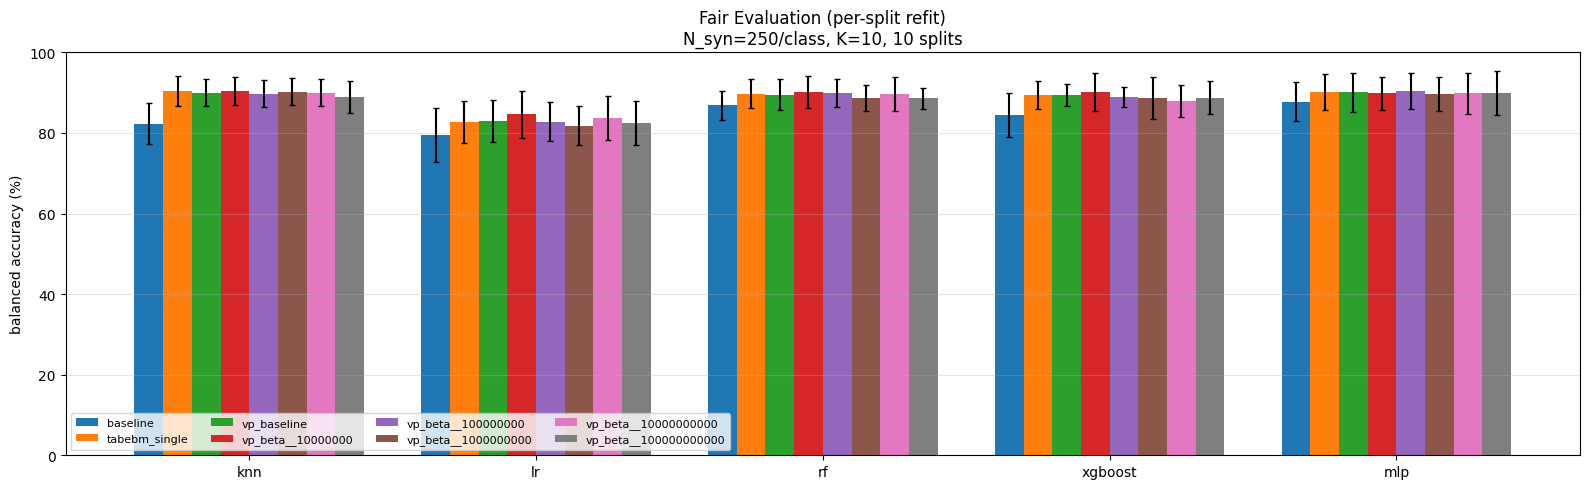

  saved: experiments/ebms/20260415_214026_Distance_EBM/fair_eval/20260417_205640/bar_bacc.png


In [22]:
n_set = len(SETTINGS)
fig, ax = plt.subplots(figsize=(max(8, 1.2*len(CLASSIFIERS)*n_set/3), 5))
x = np.arange(len(CLASSIFIERS))
w = 0.8 / n_set
for i, s in enumerate(SETTINGS):
    means = [mean_df.loc[c, s] for c in CLASSIFIERS]
    stds  = [std_df.loc[c, s]  for c in CLASSIFIERS]
    ax.bar(x + (i - (n_set-1)/2) * w, means, w, yerr=stds, label=s, capsize=2)
ax.set_xticks(x); ax.set_xticklabels(CLASSIFIERS)
ax.set_ylabel('balanced accuracy (%)')
ax.set_title(f'Fair Evaluation (per-split refit)\n'
              f'N_syn={N_SYN_PER_CLASS}/class, K={K}, {N_SPLITS} splits')
ax.legend(ncol=min(n_set, 4), fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / 'bar_bacc.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'  saved: {OUT_DIR / "bar_bacc.png"}')

## 12. VP config 요약

In [23]:
summary = []
for ci, cfg in enumerate(VP_CONFIGS):
    col = f'Δ_{VP_NAMES[ci]}'
    avg_delta = float(delta[col].mean())
    robust_count = int((delta.groupby('classifier')[col].mean() > 0).sum())
    summary.append({
        'name': VP_NAMES[ci],
        'beta': cfg['beta'], 'eta': cfg['eta'], 'tau': cfg['tau'],
        'ignore_variance': cfg.get('ignore_variance', False),
        'mean_Δ_pp': avg_delta,
        'classifiers_beating_baseline': f'{robust_count}/{len(CLASSIFIERS)}',
    })
summary_df = pd.DataFrame(summary).sort_values('mean_Δ_pp', ascending=False)
summary_df.to_csv(OUT_DIR / 'vp_config_summary.csv', index=False)
print(f'saved: {OUT_DIR / "vp_config_summary.csv"}')
summary_df

saved: experiments/ebms/20260415_214026_Distance_EBM/fair_eval/20260417_205640/vp_config_summary.csv


,name,beta,eta,tau,ignore_variance,mean_Δ_pp,classifiers_beating_baseline
1,vp_beta__10000000,1.000e+07,0.05,1.0,False,4.846,5/5
0,vp_baseline,1.000e+06,0.05,1.0,False,4.210,5/5
2,vp_beta__100000000,1.000e+08,0.05,1.0,False,4.189,5/5
4,vp_beta__10000000000,1.000e+10,0.05,1.0,False,4.044,5/5
3,vp_beta__1000000000,1.000e+09,0.05,1.0,False,3.627,5/5
5,vp_beta__100000000000,1.000e+11,0.05,1.0,False,3.544,5/5


## 13. 공정성 체크리스트

In [24]:
print('=== 공정성 체크리스트 ===')
print(f'  [✓] Data leakage:      ensemble 은 X_tr 만으로 fit (X_te 미포함)')
print(f'  [✓] Split-dependent:   split 마다 새 ensemble + 새 VP-SGLD synthetic')
print(f'  [✓] Ratio:             N_SYN_PER_CLASS={N_SYN_PER_CLASS} (논문 기준 ~1:5)')
print(f'  [✓] TabEBM single:     X_tr 만으로 per-split 생성 (논문 동일)')
print(f'  [✓] Metric:            balanced_accuracy_score (class imbalance robust)')
print(f'  [✓] Stratified split:  class 비율 보존')
print(f'  [✓] Classifier seed:   split 별 고정 (재현성)')
print(f'\n=== 결과 파일 ===')
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p.name:<30} {p.stat().st_size:>10} bytes')

=== 공정성 체크리스트 ===
  [✓] Data leakage:      ensemble 은 X_tr 만으로 fit (X_te 미포함)
  [✓] Split-dependent:   split 마다 새 ensemble + 새 VP-SGLD synthetic
  [✓] Ratio:             N_SYN_PER_CLASS=250 (논문 기준 ~1:5)
  [✓] TabEBM single:     X_tr 만으로 per-split 생성 (논문 동일)
  [✓] Metric:            balanced_accuracy_score (class imbalance robust)
  [✓] Stratified split:  class 비율 보존
  [✓] Classifier seed:   split 별 고정 (재현성)

=== 결과 파일 ===
  bar_bacc.png                        50805 bytes
  delta_vs_baseline.csv                1693 bytes
  eval_config.json                     1985 bytes
  mean_bacc.csv                         883 bytes
  per_split_ensembles                  4096 bytes
  splits_raw.csv                       7604 bytes
  std_bacc.csv                          893 bytes
  vp_config_summary.csv                 485 bytes
